# Cosmic Ray Transport

Simulating cosmic-ray transport as a stochastic pitch-angle scattering process and connecting the microscopic Monte Carlo model to macroscopic diffusion.

## Setup & Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

rng = np.random.default_rng(42)

# Global parameters
v    = 1.0
tau  = 1.0
tend = 100.0

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
print("Setup complete.")

Setup complete.
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


---
## Part 1: Sampling Exponential Waiting Times

The exponential PDF is $p(\Delta t) = \frac{1}{\tau} e^{-\Delta t / \tau}$.  
Its CDF is:
$$F(\Delta t) = \int_0^{\Delta t} \frac{1}{\tau} e^{-s/\tau}\,ds = 1 - e^{-\Delta t/\tau}$$

Setting $F(\Delta t) = u$ and solving for $\Delta t$:
$$u = 1 - e^{-\Delta t/\tau} \implies \Delta t = -\tau \ln(1 - u)$$

Since $u \sim U(0,1)$, so is $1-u$, confirming the inversion formula.

<Δt> = 1.0014  (expected τ = 1.0)


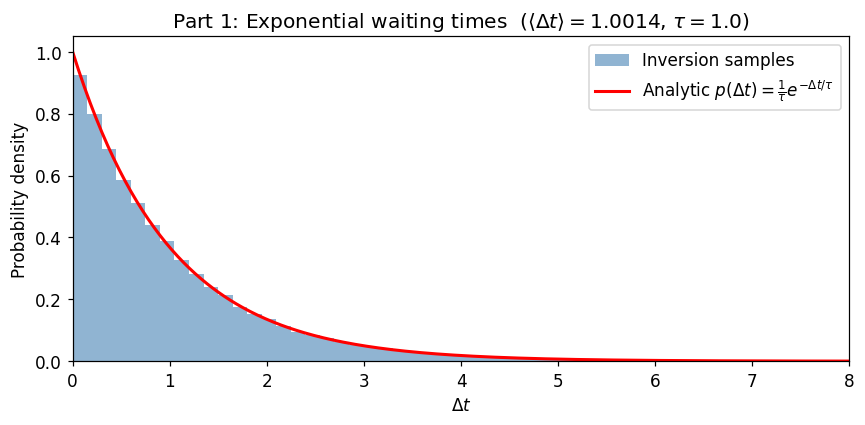

In [6]:
N = 100_000
u = rng.uniform(0, 1, N)
dt_samples = -tau * np.log(1 - u)

mean_dt = np.mean(dt_samples)
print(f"<Δt> = {mean_dt:.4f}  (expected τ = {tau})")

fig, ax = plt.subplots(figsize=(8, 4))
t_plot = np.linspace(0, 8*tau, 400)
ax.hist(dt_samples, bins=80, density=True, alpha=0.6, color='steelblue',
        label='Inversion samples')
ax.plot(t_plot, expon.pdf(t_plot, scale=tau), 'r-', lw=2,
        label=r'Analytic $p(\Delta t)=\frac{1}{\tau}e^{-\Delta t/\tau}$')
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel('Probability density')
ax.set_title(rf'Part 1: Exponential waiting times  ($\langle\Delta t\rangle={mean_dt:.4f}$, $\tau={tau}$)')
ax.legend()
ax.set_xlim(0, 8)
fig.tight_layout()
plt.show()

---
## Part 2: Sampling Isotropic Pitch Angles 

For an isotropic distribution in 3D, the solid angle element is $d\Omega = \sin\theta\,d\theta\,d\phi$.  
With $\mu = \cos\theta$: $d\Omega = d\mu\,d\phi$, so $\mu$ is **uniformly distributed** on $[-1, 1]$.

<μ>  = -0.00133  (expected 0)
<μ²> = 0.33364  (expected 1/3 ≈ 0.33333)


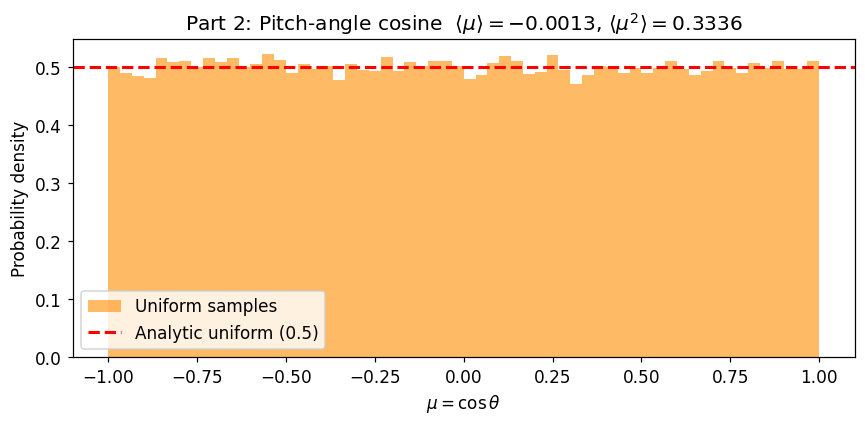

In [7]:
mu_samples = rng.uniform(-1, 1, N)
print(f"<μ>  = {np.mean(mu_samples):.5f}  (expected 0)")
print(f"<μ²> = {np.mean(mu_samples**2):.5f}  (expected 1/3 ≈ {1/3:.5f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mu_samples, bins=60, density=True, alpha=0.6, color='darkorange',
        label='Uniform samples')
ax.axhline(0.5, color='red', lw=2, ls='--', label='Analytic uniform (0.5)')
ax.set_xlabel(r'$\mu = \cos\theta$')
ax.set_ylabel('Probability density')
ax.set_title(rf'Part 2: Pitch-angle cosine  $\langle\mu\rangle={np.mean(mu_samples):.4f}$,'
             rf' $\langle\mu^2\rangle={np.mean(mu_samples**2):.4f}$')
ax.legend()
fig.tight_layout()
plt.show()

---
## Part 3: Monte Carlo Particle Trajectories

Each particle starts at $x(0)=0$, draws a random $\mu \sim U(-1,1)$, then alternates between  
ballistic motion $x \to x + v\mu\,\Delta t$ and a pitch-angle resample.

**Why diffusion emerges from ballistic segments:**  
Between scatterings each particle moves in a straight line, but after each kick $\mu$ is redrawn independently.  
The displacement increments $\delta x_i = v\mu_i \Delta t_i$ are therefore uncorrelated.  
By the Central Limit Theorem, the sum of many such independent increments produces a Gaussian distribution  
whose variance grows linearly in time — i.e. diffusion — even though no single step is diffusive.

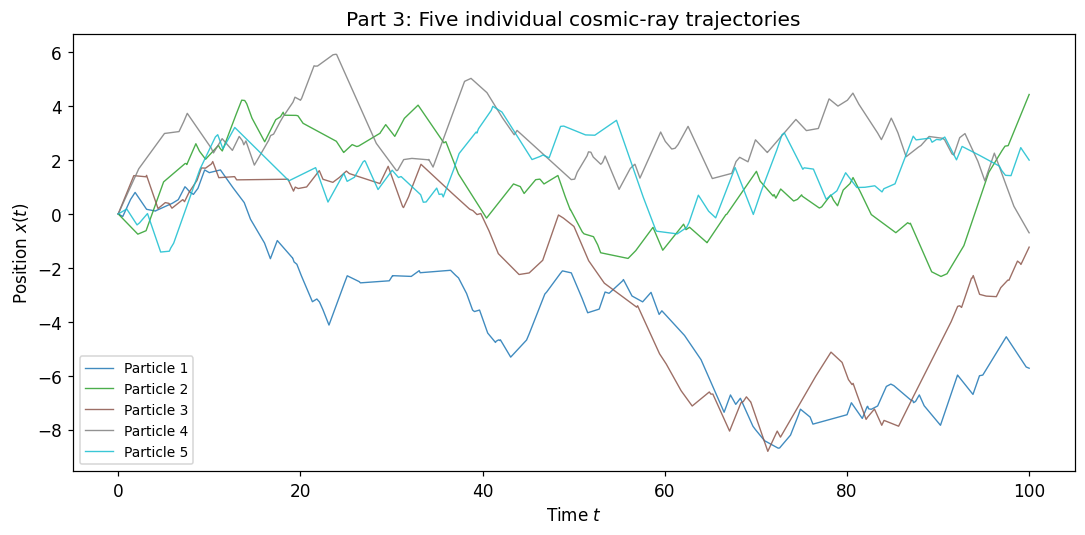

In [8]:
def simulate_particle(v, tau, tend, rng, fixed_dt=False):
    t, x = 0.0, 0.0
    mu = rng.uniform(-1, 1)
    times, positions = [t], [x]
    while t < tend:
        dt = tau if fixed_dt else -tau * np.log(1 - rng.uniform())
        if t + dt > tend:
            dt = tend - t
        x += v * mu * dt
        t += dt
        times.append(t)
        positions.append(x)
        mu = rng.uniform(-1, 1)
    return np.array(times), np.array(positions)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 5))
for i in range(5):
    t_traj, x_traj = simulate_particle(v, tau, tend, rng)
    ax.plot(t_traj, x_traj, lw=0.9, color=colors[i], alpha=0.85, label=f'Particle {i+1}')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Position $x(t)$')
ax.set_title('Part 3: Five individual cosmic-ray trajectories')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## Part 4: Ensemble Diffusion

Simulate $N_p = 10^4$ particles and track $\langle x \rangle(t)$, $\sigma^2_x(t)$, and  
$\kappa_\mathrm{MC}(t) = \sigma^2_x / 2t$, comparing to the theoretical $\kappa = \frac{1}{3}v^2\tau$.


In [9]:
Np    = 10_000
t_out = np.linspace(0.5, tend, 200)
kappa_theory = (1/3) * v**2 * tau

def run_ensemble(Np, v, tau, tend, t_out, rng, fixed_dt=False):
    x_sum  = np.zeros(len(t_out))
    x2_sum = np.zeros(len(t_out))
    for _ in range(Np):
        t, x = 0.0, 0.0
        mu = rng.uniform(-1, 1)
        out_idx = 0
        while out_idx < len(t_out):
            dt = tau if fixed_dt else -tau * np.log(1 - rng.uniform())
            t_next = t + dt
            while out_idx < len(t_out) and t_out[out_idx] <= t_next:
                x_at_t = x + v * mu * (t_out[out_idx] - t)
                x_sum[out_idx]  += x_at_t
                x2_sum[out_idx] += x_at_t**2
                out_idx += 1
            x += v * mu * dt
            t  = t_next
            mu = rng.uniform(-1, 1)
        while out_idx < len(t_out):
            x_sum[out_idx]  += x
            x2_sum[out_idx] += x**2
            out_idx += 1
    x_mean  = x_sum  / Np
    x2_mean = x2_sum / Np
    sigma2  = x2_mean - x_mean**2
    kappa_mc = sigma2 / (2 * t_out)
    return x_mean, sigma2, kappa_mc

print("Running ensemble (exponential Δt)...")
x_mean, sigma2, kappa_mc = run_ensemble(Np, v, tau, tend, t_out, rng)
print(f"Late-time κ_MC ≈ {np.mean(kappa_mc[-30:]):.4f}  (theory κ = {kappa_theory:.4f})")

Running ensemble (exponential Δt)...
Late-time κ_MC ≈ 0.3283  (theory κ = 0.3333)


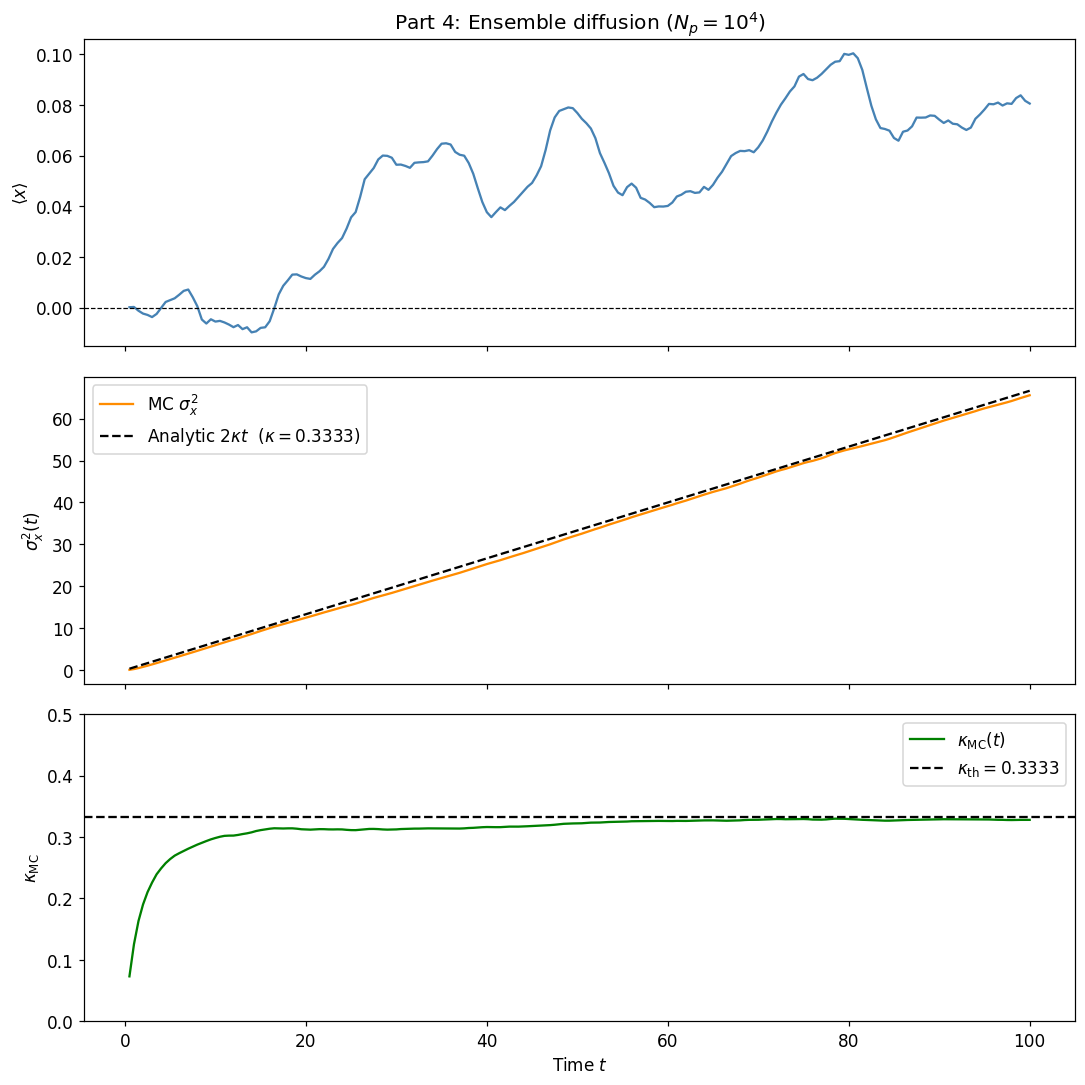


Early-time behaviour: σ²_x ~ t²  (ballistic, κ_MC rises from 0).
Late-time behaviour:  σ²_x ~ 2κt (diffusive, κ_MC → κ_th ≈ 1/3).
The crossover occurs around t ~ τ when multiple scatterings have decorrelated the motion.



In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(t_out, x_mean, color='steelblue', lw=1.5)
axes[0].axhline(0, color='k', ls='--', lw=0.8)
axes[0].set_ylabel(r'$\langle x \rangle$')
axes[0].set_title(r'Part 4: Ensemble diffusion ($N_p=10^4$)')

axes[1].plot(t_out, sigma2, color='darkorange', lw=1.5, label=r'MC $\sigma^2_x$')
axes[1].plot(t_out, 2*kappa_theory*t_out, 'k--', lw=1.5,
             label=rf'Analytic $2\kappa t$  ($\kappa={kappa_theory:.4f}$)')
axes[1].set_ylabel(r'$\sigma^2_x(t)$')
axes[1].legend()

axes[2].plot(t_out, kappa_mc, color='green', lw=1.5, label=r'$\kappa_\mathrm{MC}(t)$')
axes[2].axhline(kappa_theory, color='k', ls='--', lw=1.5,
                label=rf'$\kappa_\mathrm{{th}}={kappa_theory:.4f}$')
axes[2].set_xlabel('Time $t$')
axes[2].set_ylabel(r'$\kappa_\mathrm{MC}$')
axes[2].set_ylim(0, 1.5*kappa_theory)
axes[2].legend()

fig.tight_layout()
plt.show()

print("""
Early-time behaviour: σ²_x ~ t²  (ballistic, κ_MC rises from 0).
Late-time behaviour:  σ²_x ~ 2κt (diffusive, κ_MC → κ_th ≈ 1/3).
The crossover occurs around t ~ τ when multiple scatterings have decorrelated the motion.
""")

---
## Part 5: Incorrect Sampling — Fixed $\Delta t = \tau$

**Why microscopic sampling matters:**  
The correct exponential distribution has variance $\text{Var}(\Delta t) = \tau^2$, contributing  
extra displacement fluctuations that are essential to the diffusion coefficient.  
With a fixed $\Delta t = \tau$ the variance of waiting times is zero, which suppresses those  
fluctuations and yields $\kappa_\mathrm{MC} \approx \kappa_\mathrm{th}/2$.

Running ensemble (fixed Δt = τ)...
Fixed Δt κ_MC  ≈ 0.1651  (theory 0.3333)


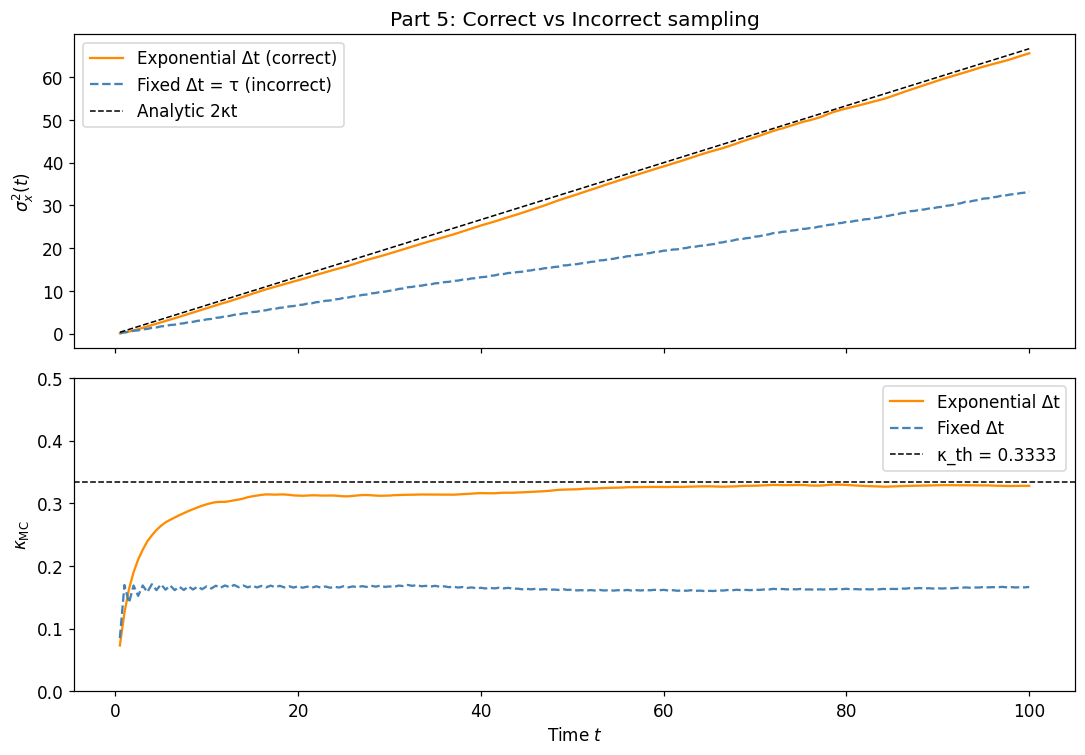

In [11]:
print("Running ensemble (fixed Δt = τ)...")
x_mean_fix, sigma2_fix, kappa_mc_fix = run_ensemble(
    Np, v, tau, tend, t_out, rng, fixed_dt=True)
print(f"Fixed Δt κ_MC  ≈ {np.mean(kappa_mc_fix[-30:]):.4f}  (theory {kappa_theory:.4f})")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t_out, sigma2,     lw=1.5, color='darkorange', label='Exponential Δt (correct)')
axes[0].plot(t_out, sigma2_fix, lw=1.5, color='steelblue', ls='--', label='Fixed Δt = τ (incorrect)')
axes[0].plot(t_out, 2*kappa_theory*t_out, 'k--', lw=1, label='Analytic 2κt')
axes[0].set_ylabel(r'$\sigma^2_x(t)$')
axes[0].set_title('Part 5: Correct vs Incorrect sampling')
axes[0].legend()

axes[1].plot(t_out, kappa_mc,     lw=1.5, color='darkorange', label='Exponential Δt')
axes[1].plot(t_out, kappa_mc_fix, lw=1.5, color='steelblue', ls='--', label='Fixed Δt')
axes[1].axhline(kappa_theory, color='k', ls='--', lw=1, label=f'κ_th = {kappa_theory:.4f}')
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel(r'$\kappa_\mathrm{MC}$')
axes[1].set_ylim(0, 1.5*kappa_theory)
axes[1].legend()

fig.tight_layout()
plt.show()

---
## Part 6: Momentum-Dependent Scattering

$\tau(p) = \tau_0 (p/p_0)^\alpha$ with $\alpha = 1/3$, giving $\kappa(p) = \frac{1}{3}\tau(p) \propto p^\alpha$.

In [12]:
alpha = 1/3
p_p0  = np.array([0.3, 1.0, 3.0, 10.0])
tau0  = 1.0
t_out6 = np.linspace(0.5, 300, 200)

kappa_mc_p, kappa_th_p = [], []

for pp in p_p0:
    tau_p    = tau0 * (pp)**alpha          # p0 = 1
    kappa_th = (1/3) * v**2 * tau_p
    kappa_th_p.append(kappa_th)
    _, _, kmc_p = run_ensemble(Np, v, tau_p, 300, t_out6, rng)
    k_late = np.mean(kmc_p[-30:])
    kappa_mc_p.append(k_late)
    print(f"p/p0={pp:5.1f}: τ={tau_p:.4f}  κ_th={kappa_th:.4f}  κ_MC={k_late:.4f}")

kappa_mc_p = np.array(kappa_mc_p)
kappa_th_p = np.array(kappa_th_p)

p/p0=  0.3: τ=0.6694  κ_th=0.2231  κ_MC=0.2202
p/p0=  1.0: τ=1.0000  κ_th=0.3333  κ_MC=0.3324
p/p0=  3.0: τ=1.4422  κ_th=0.4807  κ_MC=0.4854
p/p0= 10.0: τ=2.1544  κ_th=0.7181  κ_MC=0.6993


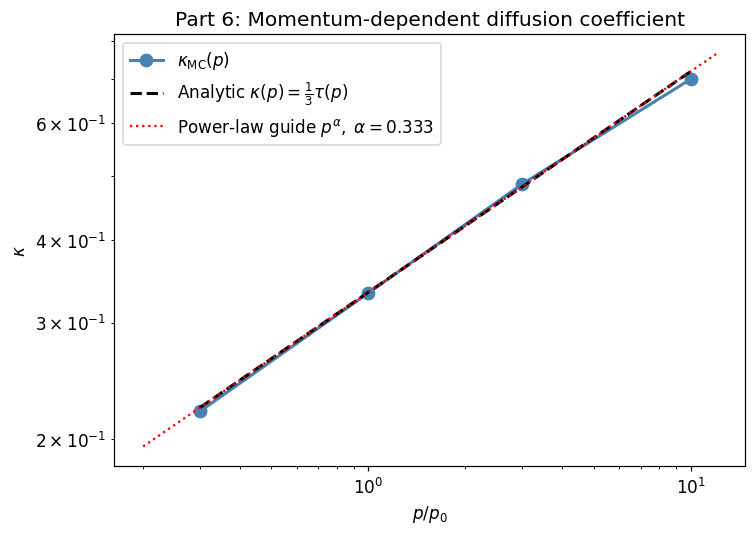

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(p_p0, kappa_mc_p, 'o-', color='steelblue', lw=2, ms=8,
          label=r'$\kappa_\mathrm{MC}(p)$')
ax.loglog(p_p0, kappa_th_p, 'k--', lw=2,
          label=r'Analytic $\kappa(p)=\frac{1}{3}\tau(p)$')
p_fit = np.array([0.2, 12])
ax.loglog(p_fit, kappa_th_p[1] * p_fit**alpha, 'r:', lw=1.5,
          label=rf'Power-law guide $p^{{\alpha}},\;\alpha={alpha:.3f}$')
ax.set_xlabel(r'$p/p_0$')
ax.set_ylabel(r'$\kappa$')
ax.set_title('Part 6: Momentum-dependent diffusion coefficient')
ax.legend()
fig.tight_layout()
plt.show()